In [1]:
import sctour as sct
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
wdir = "/media/desk16/iyun4605/projects/Everolimus_Resistance_ccRCC/analysis/data/07_mps_trajectory/03_scTour"
os.chdir(wdir)
print(os.getcwd())

/media/desk16/iyun4605/projects/Everolimus_Resistance_ccRCC/analysis/data/07_mps_trajectory/03_scTour


In [4]:
adata = sc.read_h5ad("01_mps_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 12912 × 51582
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'contamination_score', 'contamination_th_0.1', 'contamination_th_0.2', 'doublet_score', 'predicted_doublet', 'percent_mito_by_sample', 'percent_ribo_by_sample', 'percent_hb_by_sample', 'percent_hsp_by_sample', 'percent_dissociation_by_sample', 'RNA_snn_res.0.1', 'RNA_snn_res.0.15', 'RNA_snn_res.0.2', 'RNA_snn_res.0.25', 'RNA_snn_res.0.3', 'RNA_snn_res.0.35', 'RNA_snn_res.0.4', 'RNA_snn_res.0.45', 'RNA_snn_res.0.5', 'seurat_clusters', 'ERScore', 'ERScore_group', 'major_celltype_treat', 'MPS_RNA_snn_res.0.1', 'MPS_RNA_snn_res.0.15', 'MPS_RNA_snn_res.0.2', 'MPS_RNA_snn_res.0.25', 'MPS_RNA_snn_res.0.3', 'MPS_RNA_snn_res.0.35', 'MPS_RNA_snn_res.0.4', 'MPS_RNA_snn_res.0.45', 'MPS_RNA_snn_res.0.5', 'MPS_RNA_snn_res.0.55', 'MPS_RNA_snn_res.0.6', 'MPS_RNA_snn_res.0.65', 'MPS_RNA_snn_res.0.7', 'MPS_RNA_snn_res.0.75', 'MPS_RNA_snn_res.0.8', 'MPS_RNA_snn_res.0.85', 'MPS_RNA_snn_res.0.9', 'MPS_RN

In [5]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=1000, subset=True)

In [6]:
tnode = sct.train.Trainer(adata, loss_mode='nb', percent = 0.2, alpha_recon_lec=0.5, alpha_recon_lode=0.5)
tnode.train()

Running using CPU.
Epoch 400: 100%|██████████| 400/400 [38:27<00:00,  5.77s/epoch, train_loss=350, val_loss=364]


In [7]:
adata.obs['ptime'] = tnode.get_time()
mix_zs, zs, pred_zs = tnode.get_latentsp(alpha_z=0.5, alpha_predz=0.5)
adata.obsm['X_TNODE'] = mix_zs
adata.obsm['X_VF'] = tnode.get_vector_field(adata.obs['ptime'].values, adata.obsm['X_TNODE'])

/media/desk16/iyun4605/miniforge3/envs/scTour/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/desk16/iyun4605/miniforge3/envs/scTour/lib/python3.11/site-packages/sctour/vector_field.py:109: RuntimeWarning: invalid value encountered in divide
  cos_sim = np.einsum("ij, j", dZ, V[i]) / (l2_norm(dZ, axis = 1) * l2_norm(V[i]))


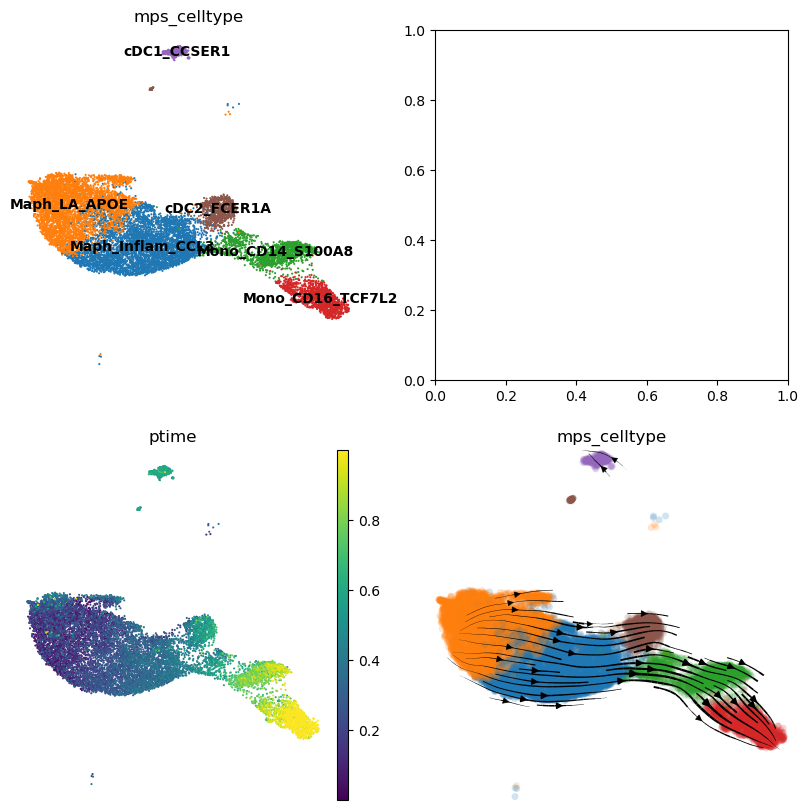

In [9]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
sc.pl.umap(adata, color='mps_celltype', ax=axs[0, 0], legend_loc='on data', show=False, frameon=False)
sc.pl.umap(adata, color='ptime', ax=axs[1, 0], show=False, frameon=False)
sct.vf.plot_vector_field(adata, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE', color='mps_celltype', show=False, ax=axs[1, 1], legend_loc='none', frameon=False, size=100, alpha=0.2)
plt.show()

/media/desk16/iyun4605/miniforge3/envs/scTour/lib/python3.11/site-packages/sctour/vector_field.py:109: RuntimeWarning: invalid value encountered in divide
  cos_sim = np.einsum("ij, j", dZ, V[i]) / (l2_norm(dZ, axis = 1) * l2_norm(V[i]))


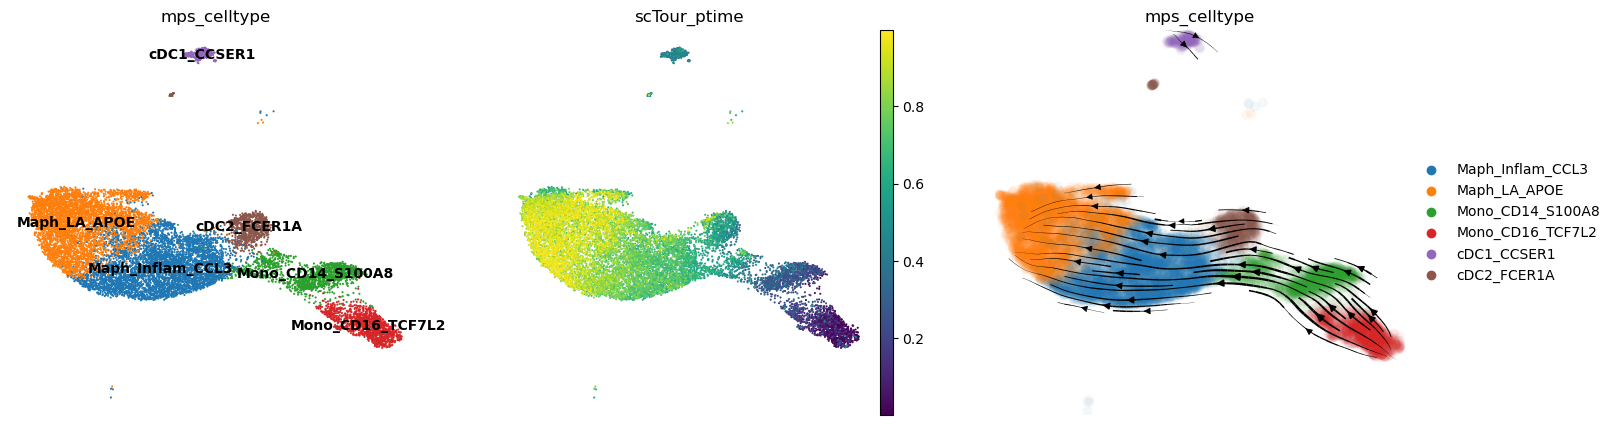

In [11]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(18, 5))
sc.pl.umap(adata, color='mps_celltype', legend_loc='on data', show=False, ax=axs[0], frameon=False)

##reverse pseudotime
adata.obs['scTour_ptime'] = sct.train.reverse_time(adata.obs['ptime'].values)
sc.pl.umap(adata, color='scTour_ptime', show=False, ax=axs[1], frameon=False)

##reverse vector field
sct.vf.plot_vector_field(adata, reverse=True, zs_key='X_TNODE', vf_key='X_VF', use_rep_neigh='X_TNODE', color='mps_celltype', show=False, ax=axs[2], frameon=False, size=200, alpha=0.05)
plt.show()

In [14]:
adata

AnnData object with n_obs × n_vars = 43846 × 1000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Contamination_score', 'percent_mito_by_sample', 'percent_ribo_by_sample', 'percent_hb_by_sample', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'sample_group', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'RNA_snn_res.0.9', 'RNA_snn_res.1', 'seurat_clusters', 'UMAP_1', 'UMAP_2', 'second_level_annotation', 'seurat_clusters_filtered', 'cell_type', 'nCount_UCellRanks', 'nFeature_UCellRanks', 'Everolimus_Resistance_Score', 'Everolimus_Resistance_Group', 'cell_type_plot', 'MPS_RNA_snn_res.0.1', 'MPS_RNA_snn_res.0.2', 'MPS_RNA_snn_res.0.3', 'MPS_RNA_snn_res.0.4', 'MPS_RNA_snn_res.0.5', 'MPS_RNA_snn_res.0.6', 'MPS_RNA_snn_res.0.7', 'MPS_RNA_snn_res.0.8', 'MPS_RNA_snn_res.0.9', 'MPS_RNA_snn_res.1', 'MPS_clusters', 'MPS_cell_type', 'n_genes_by_counts', 'total_counts', 'ptime', 'scTour_pt

In [12]:
adata.obs.to_csv('02_sctour_ptime.csv', index=True)

In [13]:
adata.write_h5ad("02_sctour_adata.h5ad")